In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

We are provided test and train data . But as we do not have the test labels so to make sure our model is working we will split our train data into train+validation data .So ,our workflow is 
(1)Load all labeled training images
(2)train_test_split with 80/20 (stratify by label length if possible)
(3)Train on 80%, evaluate CER on 20%
(4)Once satisfied with val CER → run inference on the actual test images → submit CSV

In [2]:
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, Subset
import pandas as pd

train_dir = "data/cig_ps/train_images"
labels_csv = "data/cig_ps/train-labels.csv"

labels_df = pd.read_csv(labels_csv, dtype={"image": str, "text": str})
labels_df["image"] = labels_df["image"].str.strip()
labels_df["text"] = labels_df["text"].str.strip()
label_map = dict(zip(labels_df["image"], labels_df["text"]))

transform = transforms.Compose([
    ToTensor(),
    transforms.ConvertImageDtype(torch.float32)
])

Duee to some error these are not able to load correctly eg '5.40E+12'.It is due to a type or conversion issue .Hence , it is better to drop these rows.

In [3]:
not6 = labels_df[labels_df["text"].str.len() != 6]
print(not6["text"].tolist())
print(not6['image'].tolist())
print("Count:", len(not6))

['5.40E+12', '04-Mar-54']
['train-2184.png', 'train-6819.png']
Count: 2


In [4]:
labels_df = labels_df[labels_df["text"].str.len() == 6].reset_index(drop=True)
label_map = dict(zip(labels_df["image"], labels_df["text"]))
print("Remaining rows:", len(labels_df))

Remaining rows: 19998


In [5]:
class TrainImageDataset(Dataset):
    def __init__(self, root, label_map, transform=None):
        self.root = root
        self.label_map = label_map
        self.transform = transform
        self.samples = sorted(
            [fname for fname in os.listdir(root)
             if fname.lower().endswith(".png") and fname in self.label_map]
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename = self.samples[idx]
        path = os.path.join(self.root, filename)
        image = Image.open(path).convert("L")
        if self.transform is not None:
            image = self.transform(image)
        label = self.label_map[filename]
        return image, label

In [6]:
full_dataset = TrainImageDataset(train_dir, label_map, transform=transform)

In [7]:
split_labels = [label_map[fname] for fname in full_dataset.samples]
label_lengths = [len(label) for label in split_labels]

train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    train_size=0.8,
    random_state=42,
    shuffle=True
)

train_data = Subset(full_dataset, train_idx)
val_data = Subset(full_dataset, val_idx)

print(f"Total images: {len(full_dataset)}")
print(f"Train split: {len(train_data)}")
print(f"Validation split: {len(val_data)}")

Total images: 19998
Train split: 15998
Validation split: 4000


In [8]:
print(full_dataset.samples[:5])
print(list(label_map.keys())[:10])

['train-0.png', 'train-1.png', 'train-10.png', 'train-100.png', 'train-1000.png']
['train-0.png', 'train-1.png', 'train-2.png', 'train-3.png', 'train-4.png', 'train-5.png', 'train-6.png', 'train-7.png', 'train-8.png', 'train-9.png']


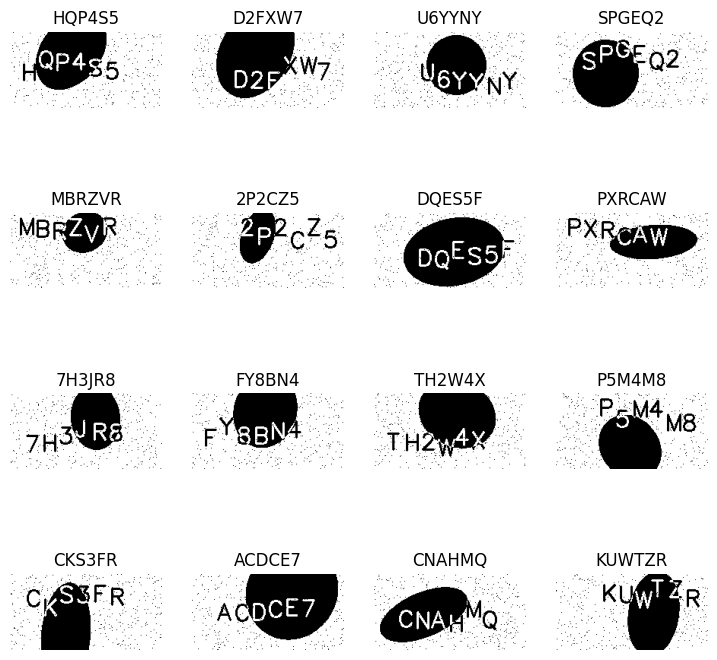

In [9]:
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    if img.ndim == 3 and img.shape[0] == 1:
        plt.imshow(img.squeeze(), cmap="gray")
    else:
        plt.imshow(img.permute(1, 2, 0).cpu())
    plt.title(label)
    plt.axis(False)
plt.show()

In [10]:
chars = set()

for text in labels_df["text"].astype(str):
    chars.update(text)

print("Unique characters:", sorted(chars))
print("Count:", len(chars))

Unique characters: ['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Count: 31


In [11]:
img,label=train_data[0]
img.shape

torch.Size([1, 100, 200])

In [12]:
vocab = sorted(chars)
char_to_idx = {c: i + 1 for i, c in enumerate(vocab)}  # 0 reserved for CTC blank
idx_to_char = {i + 1: c for i, c in enumerate(vocab)}
print(char_to_idx)

{'2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'J': 17, 'K': 18, 'M': 19, 'N': 20, 'P': 21, 'Q': 22, 'R': 23, 'S': 24, 'T': 25, 'U': 26, 'V': 27, 'W': 28, 'X': 29, 'Y': 30, 'Z': 31}


In [13]:
def collate_fn(batch):
    images, labels = zip(*batch)
    images = torch.stack(images, 0)  # (B, 1, H, W)

    # encode labels to indices
    encoded = [torch.tensor([char_to_idx[c] for c in lbl], dtype=torch.long) for lbl in labels]
    label_lengths = torch.tensor([len(e) for e in encoded], dtype=torch.long)
    padded_labels = torch.nn.utils.rnn.pad_sequence(encoded, batch_first=True, padding_value=0)

    return images, padded_labels, label_lengths

In [14]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)